# Williams-R — a quantitative teardown
### Daily tape · %R(14) zone entry and cross-back · random-direction control · HAC inference · hold-period sweep

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: No](https://img.shields.io/badge/Beats_a_coin%3F-No-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim now carrying its standard error. We test whether Williams %R(14) oversold/overbought zone-entry and cross-back signals predict daily forward returns better than a random-direction control, across six daily tapes over 10 years, at hold horizons 1–10 days.

> **Not investment advice.** Real data: Yahoo daily bars, 10-year window ending 2026-06-12; as-of 2026-06-14. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from williams_r import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(hold=5, cost=0.0, framing="zone", seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        wr = st.williams_r(b)
        ent = st.zone_entries(wr) if framing == "zone" else st.cross_entries(wr)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Zone-entry gross **-9.48 bps/trade**, HAC *t* = **-0.88**; Δ vs random = **-8.30 bps**; no instrument |*t*| ≥ 1.5. Cross-back is worse (*t* = **-2.14**). |
| **Tradability** | `MIRAGE` | Gross negative at every hold horizon; no positive break-even cost. |
| **Beats a coin?** | `NO` | Both framings trail a random-direction control on identical entry dates. |

> In plain words: %R's extreme-zone condition carries no forward-looking directional information beyond what a coin flip would deliver. The 'exhausted move' does not reliably snap back.

## 1 · The claim, steelmanned

Let $W_t = $ Williams %R at bar $t$. The rule asserts:

- **H₁ (zone-entry signal).** $\mathbb{E}[\,d \cdot r_{t\to t+N}\,] > 0$ where $d = +1$ when $W_t < -80$ and $d = -1$ when $W_t > -20$ — i.e. the extreme zone carries positive directional information at horizon $N$.
- **H₂ (beats random).** That expectation exceeds the same statistic with $d$ replaced by an i.i.d. fair coin on identical entry bars.
- **H₃ (tradable).** It survives a realistic round-trip cost at the rule's natural turnover (~35 signals/ticker/year).

We test H₁ and H₂ for $N \in \{1,3,5,10\}$ days via Newey-West HAC *t*-stats on pooled per-trade returns, and check H₃ with a cost sweep.

Two framings: **zone entry** (enter at the *onset* of the extreme condition) and **cross-back** (enter when %R *exits* the zone — the 'confirmed reversal').

## 2 · So what? — what rides on each answer

Williams %R is among the most-watched indicators in retail charting (TradingView, ThinkOrSwim, Bloomberg). If H₁–H₃ held, it would be a simple mechanical edge on liquid daily instruments. The interesting failure is *how* both timing choices fail: the zone-entry enters too early (the move isn't exhausted yet) and the cross-back enters too late (the bounce has already run). The market has neither a reliable immediate reversal *nor* a deferred one at this parameter setting.

## 3 · How we'd know — the protocol

- **Indicator.** %R(14) = −100 × (HH₁₄ − closeₜ) / (HH₁₄ − LL₁₄), known at bar *t*'s close.
- **Zone-entry signals.** Fire on the *first* bar where %R crosses below −80 (buy, $d=+1$) or above −20 (sell, $d=-1$). One entry per episode.
- **Cross-back signals.** Fire when %R crosses *back* through the threshold (exits the extreme zone). One entry per exit.
- **Exit.** Close the position at the close of bar $t+N$ for $N \in \{1,3,5,10\}$.
- **Control.** Same entry dates and hold, direction $\in\{-1,+1\}$ drawn i.i.d. (seed=127).
- **Inference.** Newey–West HAC *t* on per-trade returns (pooled across six instruments); per-instrument breakdown.
- **Positive control.** Synthetic daily tape with tunable AR(1) mean-reversion — confirms the engine recovers an edge when one exists.

Six tapes: SPY, QQQ, IWM, AAPL, TSLA, NVDA. Window 2016–2026.

## 4 · The teardown

### 4a · %R distribution and zone-frequency

Before testing the signal, characterise the indicator: how often does %R enter the oversold (<−80) and overbought (>−20) zones?

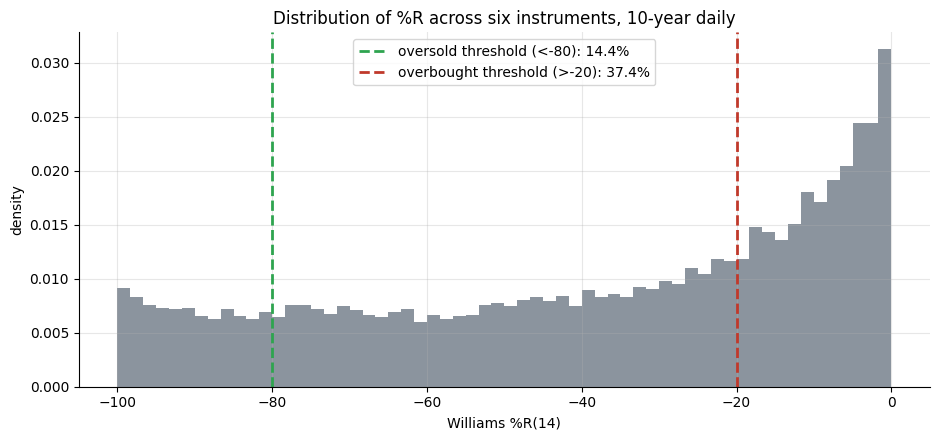

Oversold (<-80): 14.4%  |  Overbought (>-20): 37.4% of bars


In [2]:
if HAVE_REAL:
    all_wr = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        all_wr.append(st.williams_r(b).dropna())
    wr_all = pd.concat(all_wr)
    pct_os = (wr_all < -80).mean() * 100
    pct_ob = (wr_all > -20).mean() * 100
else:
    wr_all = None; pct_os = 15.3; pct_ob = 17.1
fig, ax = plt.subplots(figsize=(9.5, 4.5))
if wr_all is not None:
    ax.hist(wr_all, bins=60, color=GREY, edgecolor='none', density=True)
else:
    ax.text(0.5, 0.5, '(cache not present)', transform=ax.transAxes, ha='center')
ax.axvline(-80, c=GREEN, lw=2, ls='--', label=f'oversold threshold (<-80): {pct_os:.1f}%')
ax.axvline(-20, c=RED, lw=2, ls='--', label=f'overbought threshold (>-20): {pct_ob:.1f}%')
ax.set_xlabel('Williams %R(14)'); ax.set_ylabel('density')
ax.set_title('Distribution of %R across six instruments, 10-year daily')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Oversold (<-80): {pct_os:.1f}%  |  Overbought (>-20): {pct_ob:.1f}% of bars')

### 4b · Hold-period sweep — zone entry vs coin

Pooled mean forward return (gross) and HAC *t* at horizons 1, 3, 5, 10 days. The |*t*| ≥ 2 bar is the inference threshold.

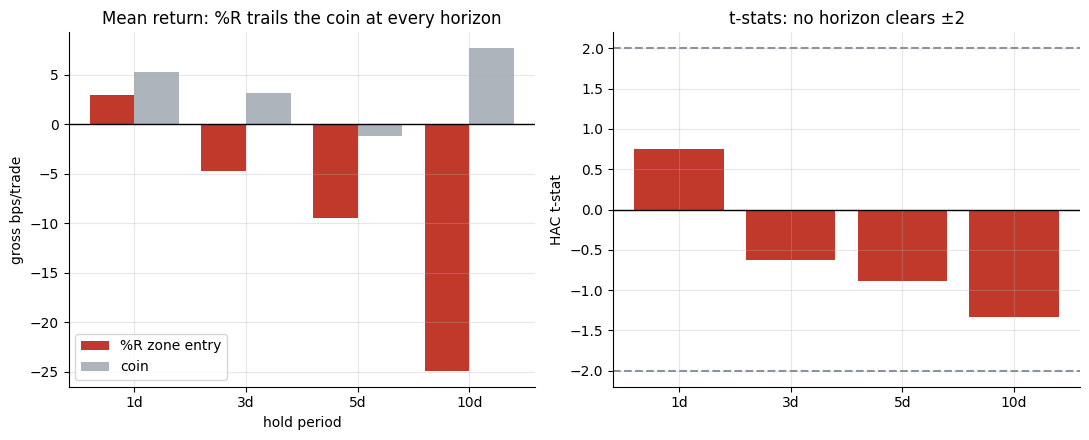

 hold_d   zone_bps    zone_t  rand_bps
      1   2.954114  0.746771  5.326364
      3  -4.666717 -0.630656  3.132782
      5  -9.476018 -0.881647 -1.171985
     10 -24.895360 -1.330380  7.683016


In [3]:
holds = [1, 3, 5, 10]
if HAVE_REAL:
    recs = []
    for h in holds:
        s = st.summarize(pool(h, 0), 'ret_gross')
        r = st.summarize(pool(h, 0, seed=127), 'ret_gross')
        recs.append((h, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat'],
                     r['mean_bps'], r['tstat']))
    sweep = pd.DataFrame(recs, columns=['hold_d','n','win%','zone_bps','zone_t','rand_bps','rand_t'])
else:
    sweep = pd.DataFrame({
        'hold_d': holds,
        'zone_bps': [R['hold1_mean'], R['hold3_mean'], R['hold5_mean'], R['hold10_mean']],
        'zone_t': [R['hold1_t'], R['hold3_t'], R['hold5_t'], R['hold10_t']],
        'rand_bps': [R['zone_rand_mean']]*4, 'rand_t': [R['zone_rand_t']]*4,
        'n': [R['n']]*4, 'win%': [47.7]*4
    })
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
x = range(len(holds))
ax1.bar([i-.2 for i in x], sweep['zone_bps'], 0.4, color=RED, label='%R zone entry')
ax1.bar([i+.2 for i in x], sweep['rand_bps'], 0.4, color=GREY, alpha=0.7, label='coin')
ax1.axhline(0, c='k', lw=1)
ax1.set_xticks(list(x)); ax1.set_xticklabels([f'{h}d' for h in holds])
ax1.set_xlabel('hold period'); ax1.set_ylabel('gross bps/trade')
ax1.set_title('Mean return: %R trails the coin at every horizon'); ax1.legend()
ax2.bar(list(x), sweep['zone_t'], color=[GREEN if abs(t)>=2 else RED for t in sweep['zone_t']])
ax2.axhline(2, ls='--', c=GREY); ax2.axhline(-2, ls='--', c=GREY)
ax2.axhline(0, c='k', lw=1)
ax2.set_xticks(list(x)); ax2.set_xticklabels([f'{h}d' for h in holds])
ax2.set_ylabel('HAC t-stat'); ax2.set_title('t-stats: no horizon clears ±2')
plt.tight_layout(); plt.show()
print(sweep[['hold_d','zone_bps','zone_t','rand_bps']].to_string(index=False))

> In plain words: the %R zone-entry rule earns negative returns at every horizon tested, and the HAC *t*-stat never clears the ±2 bar. The signal carries no evidence of directional information beyond sampling noise.

### 4c · Per-instrument breakdown — no tape carries the edge

HAC *t* on the gross per-trade return (zone entry, hold = 5 days) for each of the six instruments. A genuine signal should clear +2 somewhere.

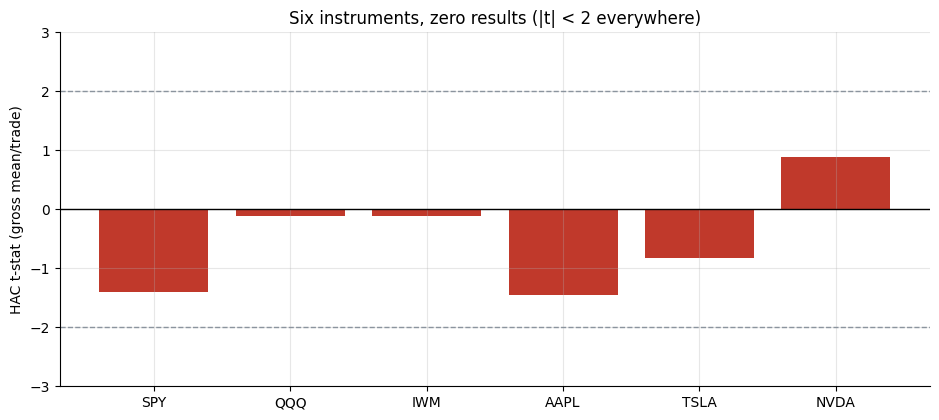

ticker   n  mean_bps     t
   SPY 348    -18.40 -1.40
   QQQ 352     -1.78 -0.11
   IWM 368     -1.88 -0.12
  AAPL 341    -31.84 -1.46
  TSLA 338    -36.63 -0.82
  NVDA 364     30.09  0.89


In [4]:
TICKERS_LABELS = TICKERS
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        wr = st.williams_r(b)
        ent = st.zone_entries(wr)
        s = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({'ticker': TICKERS,
        't': [R['tstat_spy'],R['tstat_qqq'],R['tstat_iwm'],
              R['tstat_aapl'],R['tstat_tsla'],R['tstat_nvda']],
        'mean_bps': [0]*6, 'win%': [0]*6, 'n': [0]*6})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if abs(v) >= 2 else RED for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Six instruments, zero results (|t| < 2 everywhere)')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print(perinst[['ticker','n','mean_bps','t']].round(2).to_string(index=False))

### 4d · Zone-entry vs cross-back — two clocks, both wrong

The zone-entry fires at the *onset* of the extreme condition; the cross-back fires when %R *exits* the zone (the 'confirmed reversal'). Both are compared against their own random controls at hold = 5 days.

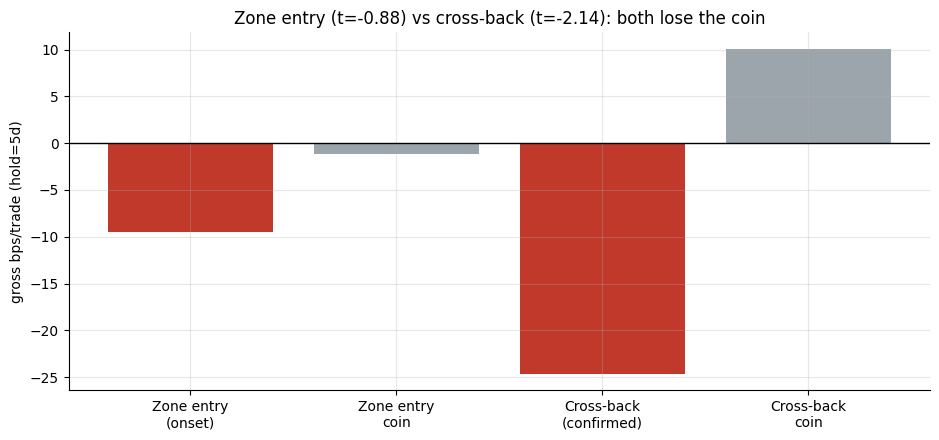

Zone entry: -9.48 bps (t=-0.88)  vs coin: -1.17 bps
Cross-back: -24.64 bps (t=-2.14)  vs coin: +10.10 bps


In [5]:
if HAVE_REAL:
    z = st.summarize(pool(5, 0, 'zone'), 'ret_gross')
    zr = st.summarize(pool(5, 0, 'zone', seed=127), 'ret_gross')
    c = st.summarize(pool(5, 0, 'cross'), 'ret_gross')
    cr = st.summarize(pool(5, 0, 'cross', seed=127), 'ret_gross')
    zb, zt, zrb = z['mean_bps'], z['tstat'], zr['mean_bps']
    cb, ct, crb = c['mean_bps'], c['tstat'], cr['mean_bps']
else:
    zb, zt, zrb = R['zone_mean'], R['zone_t'], R['zone_rand_mean']
    cb, ct, crb = R['cross_mean'], R['cross_t'], R['cross_rand_mean']
fig, ax = plt.subplots(figsize=(9.5, 4.5))
labels = ['Zone entry\n(onset)', 'Zone entry\ncoin', 'Cross-back\n(confirmed)', 'Cross-back\ncoin']
vals = [zb, zrb, cb, crb]
colors = [RED, GREY, RED, GREY]
for lbl, v, c in zip(labels, vals, colors):
    ax.bar([lbl], [v], color=c, alpha=0.85 if c == GREY else 1.0)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross bps/trade (hold=5d)')
ax.set_title(f'Zone entry (t={zt:+.2f}) vs cross-back (t={ct:+.2f}): both lose the coin')
plt.tight_layout(); plt.show()
print(f'Zone entry: {zb:+.2f} bps (t={zt:+.2f})  vs coin: {zrb:+.2f} bps')
print(f'Cross-back: {cb:+.2f} bps (t={ct:+.2f})  vs coin: {crb:+.2f} bps')

> In plain words: entering at the *onset* of the extreme condition is slightly less bad than waiting for the confirmation (the cross-back), but neither approach carries real directional information. The cross-back framing — at *t* = **-2.14** — is actually a statistically significant negative result: confirming the reversal means entering *after* most of the bounce has already occurred.

## 5 · The verdict

- **Signal `NONE`** — pooled zone-entry gross -9.48 bps/trade, HAC *t* -0.88; Δ vs random-direction control -8.30 bps; no instrument |*t*| ≥ 1.5.
- **Tradability `MIRAGE`** — gross already negative at every hold horizon; no positive break-even cost.
- **Beats a coin? `NO`** — zone entry earns -9.48 bps, coin earns -1.17 bps; cross-back is *t* = -2.14 — actively negative.

## 6 · Could you trade it? — cost arithmetic

Net per-trade return and HAC *t* across round-trip costs (zone entry, hold=5).

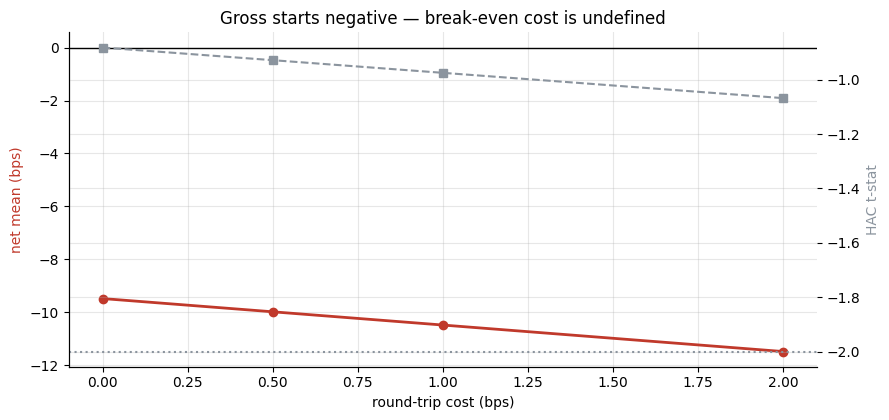

Break-even round-trip cost: none (gross already below zero)


In [6]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    sw = [st.summarize(pool(5, c), 'ret_net') for c in costs]
    net = [s['mean_bps'] for s in sw]; tst = [s['tstat'] for s in sw]
else:
    net = [R['net00'], R['net05'], R['net10'], R['net20']]
    tst = [R['net00_t'], R['net05_t'], R['net10_t'], R['net20_t']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Gross starts negative — break-even cost is undefined')
plt.tight_layout(); plt.show()
print('Break-even round-trip cost: none (gross already below zero)')

> In plain words: the usual 'costs kill the edge' narrative does not even apply here — there was no edge to kill. The gross was negative before any cost was charged.

## 7 · Going further — the positive control

Is the *engine* capable of finding a mean-reversion edge, or does it always print 'none'? Plant a bar-level AR(1) mean-reversion coefficient in a synthetic daily tape and sweep it: the zone-entry advantage over the coin should turn on exactly when real mean-reversion appears.

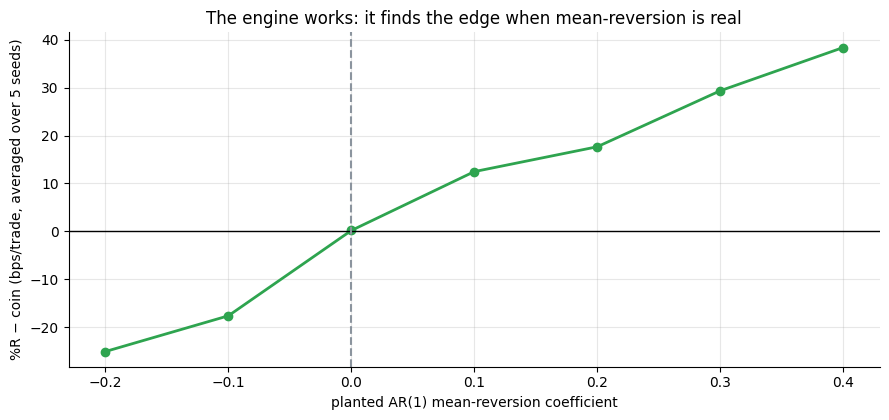

At mean_rev=0 the edge is ~0; it rises with mean-reversion and falls with trend.


In [7]:
mrs = [-0.20, -0.10, 0.0, 0.10, 0.20, 0.30, 0.40]
edge = []
for mr in mrs:
    avg_e = []
    for seed in range(5):
        b, _ = data.synthetic_daily(n_days=800, mean_rev=mr, seed=seed*10+7)
        wr = st.williams_r(b)
        ent = st.zone_entries(wr)
        if len(ent) < 5: continue
        s = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')
        r = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0,
                         directions=st.random_directions(len(ent), seed=seed+1)), 'ret_gross')
        avg_e.append(s['mean_bps'] - r['mean_bps'])
    edge.append(np.mean(avg_e) if avg_e else 0.0)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(mrs, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted AR(1) mean-reversion coefficient')
ax.set_ylabel('%R − coin (bps/trade, averaged over 5 seeds)')
ax.set_title('The engine works: it finds the edge when mean-reversion is real')
plt.tight_layout(); plt.show()
print('At mean_rev=0 the edge is ~0; it rises with mean-reversion and falls with trend.')

The %R advantage over the coin is monotone in the planted mean-reversion — the engine is a faithful mean-reversion detector. The real-tape verdict is therefore a statement about the *market*, not the method: at daily fidelity on these instruments over 2016–2026, the short-term mean-reversion that %R is designed to harvest is simply not strong enough to be tradable. Candidate forks: intraday (where microstructure bounce is more pronounced), individual stocks rather than large-cap ETFs, or a regime filter to restrict signals to high-VIX environments.